In [19]:
!pip install ultralytics
from ultralytics import YOLO
import cv2
import pandas as pd
from PIL import Image
import io
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import cv2
import json
import matplotlib.patches as patches

In [30]:
model = YOLO("yolov8n.pt")
results = model.predict(Image.open('stopped_frame.jpg'),classes=[0],conf=0.2,show=True)


0: 384x640 12 persons, 167.4ms
Speed: 4.8ms preprocess, 167.4ms inference, 6.1ms postprocess per image at shape (1, 3, 384, 640)


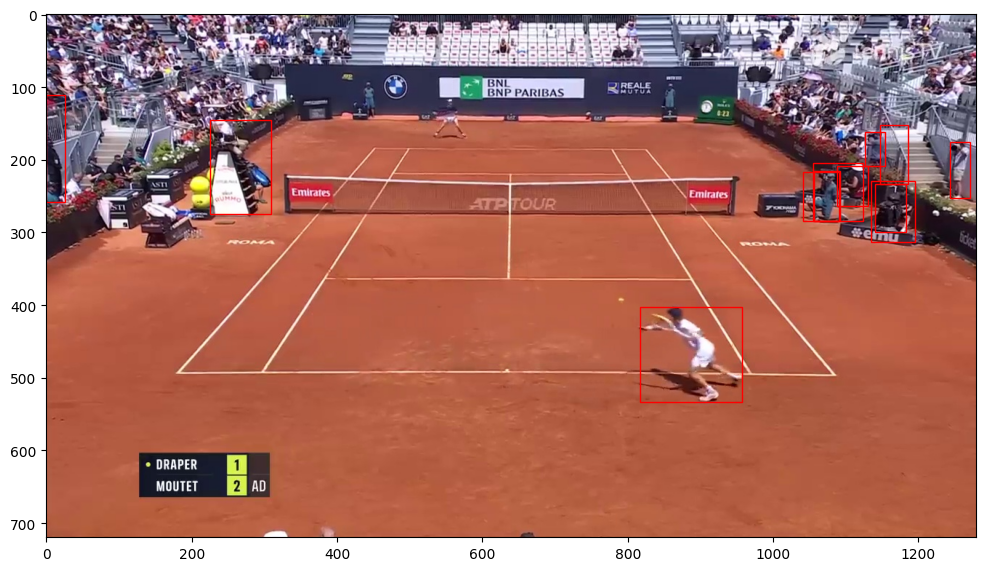

In [31]:
image_data = Image.open('stopped_frame.jpg')
fig, ax = plt.subplots(1, figsize=(12, 8))
image_plot = ax.imshow(image_data)
boxes = []
for result in results:
    for box in result.boxes.xywh.tolist():
        ax.add_patch(patches.Rectangle((box[0] - box[2]/2, box[1] - box[3]/2), box[2], box[3], linewidth=1, edgecolor='r', facecolor='none'))
    boxes.append(result.boxes.xyxy.tolist())
plt.show()